Shape: (45211, 17)
y
no     39922
yes     5289
Name: count, dtype: int64

y
no     0.883
yes    0.117
Name: proportion, dtype: float64

Missing values in the whole dataset: 0


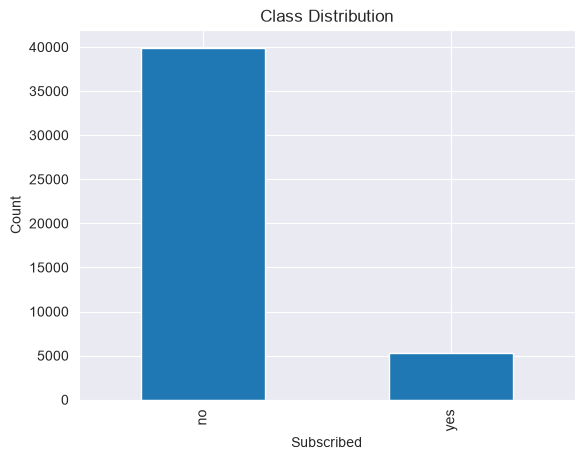

Features after one-hot encoding: 51
Train: (36168, 51)  Test: (9043, 51)

Class balance in the training set (still imbalanced at this point):
y
0    0.883
1    0.117
Name: proportion, dtype: float64


,Accuracy,Precision,Recall,F1,ROC-AUC
max_depth,,,,,
3,0.900,0.630,0.347,0.447,0.820
5,0.899,0.650,0.305,0.415,0.857
7,0.899,0.610,0.374,0.464,0.864
9,0.900,0.608,0.417,0.495,0.852
None,0.875,0.465,0.475,0.470,0.701


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

RANDOM_STATE = 42  # fixed seed so every run gives the same results

# --- Load the dataset ---
df = pd.read_csv('bank-full.csv', sep=';')
print('Shape:', df.shape)
df.head()

# --- EDA recap ---
print(df['y'].value_counts())
print()
print(df['y'].value_counts(normalize=True).round(3))
print()
print('Missing values in the whole dataset:', df.isna().sum().sum())

df['y'].value_counts().plot(kind='bar', title='Class Distribution', xlabel='Subscribed', ylabel='Count')
plt.show()

# --- Data preparation encode target, encode, split, scale ---
# 1. target: yes -> 1, no -> 0
df['y'] = (df['y'] == 'yes').astype(int)

numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# 2. encode every categorical column
X = pd.get_dummies(df.drop(columns='y'))
y = df['y']
print('Features after one-hot encoding:', X.shape[1])

# 3. train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# 4. numeric features (fit on train only)
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('Train:', X_train.shape, ' Test:', X_test.shape)
print()
print('Class balance in the training set (still imbalanced at this point):')
print(y_train.value_counts(normalize=True).round(3))

# --- Evaluation helper ---
def evaluate(model):
    """Return a dict of test-set metrics for a fitted model."""
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {'Accuracy':  accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred),
            'Recall':    recall_score(y_test, pred),
            'F1':        f1_score(y_test, pred),
            'ROC-AUC':   roc_auc_score(y_test, proba)}

# --- Baseline Decision Tree trained directly on the IMBALANCED training set ---
dt_base_models, dt_base_results = {}, {}

for depth in [3, 5, 7, 9, None]:          # None = grow the tree fully
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    dt_base_models[str(depth)] = model
    dt_base_results[str(depth)] = evaluate(model)

dt_base_results = pd.DataFrame(dt_base_results).T.round(3)
dt_base_results.index.name = 'max_depth'
dt_base_results

# --- Baseline Decision Tree best model evaluation ---
best_depth_base = dt_base_results['F1'].idxmax()
dt_base_best = dt_base_models[best_depth_base]
print('Best baseline decision tree: max_depth =', best_depth_base)
print()
print(classification_report(y_test, dt_base_best.predict(X_test), target_names=['no', 'yes']))

ConfusionMatrixDisplay.from_estimator(dt_base_best, X_test, y_test, display_labels=['no', 'yes'])
plt.title('Decision Tree (baseline, imbalanced training data) — Confusion Matrix')
plt.show()